In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [7]:
df = pd.read_csv("../data/titanic.csv", index_col="PassengerId")
df.head(5)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


In [ ]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df.duplicated().sum()

0

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

0

In [ ]:
df["Sex"].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [ ]:
df["Sex"] = df["Sex"].map({"male": 0, "female":1})

In [ ]:
df.drop(columns=["Ticket"], axis="columns", inplace=True)

In [ ]:
df.head(3)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,7.9250,NaN,S


<Axes: >

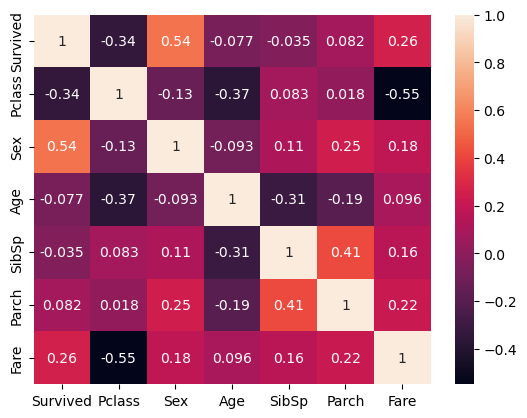

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

As we can see the most impact on surviving is based on "Sex", "Pclass" and "Fare", in numeric data.

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Cabin       687
Embarked      2
dtype: int64


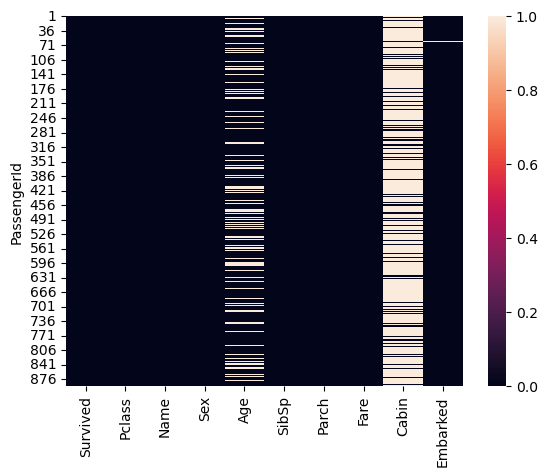

In [ ]:
print(df.isnull().sum())
sns.heatmap(df.isnull())
plt.show()

In [ ]:
df.dtypes

Survived      int64
Pclass        int64
Name         object
Sex           int64
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Cabin        object
Embarked     object
dtype: object

In [ ]:
print(df["Sex"].value_counts())
print("-"*50)
# print(df["Ticket"].value_counts())
# print("-"*50)
print(df["Cabin"].value_counts())
print("-"*50)
print(df["Embarked"].value_counts())
print("-"*50)
print(df["Pclass"].value_counts())

Sex
0    577
1    314
Name: count, dtype: int64
--------------------------------------------------
Cabin
B96 B98        4
G6             4
C23 C25 C27    4
C22 C26        3
F33            3
              ..
E34            1
C7             1
C54            1
E36            1
C148           1
Name: count, Length: 147, dtype: int64
--------------------------------------------------
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64
--------------------------------------------------
Pclass
3    491
1    216
2    184
Name: count, dtype: int64


In [ ]:
filling_age = df.groupby(["Sex", "Pclass"])

In [ ]:
df["Sex"].dtype, df["Pclass"].dtype , df["Age"].dtype

(dtype('int64'), dtype('int64'), dtype('float64'))

In [ ]:
df.groupby(['Sex', 'Pclass']).median(numeric_only=True)['Age']

Sex  Pclass
0    1         40.0
     2         30.0
     3         25.0
1    1         35.0
     2         28.0
     3         21.5
Name: Age, dtype: float64

### Filling Age null values 

based on 'Pclass' and 'Age' group median as they have more corr together and with Survivals

In [ ]:
df["Age"] = df["Age"].fillna(df.groupby(['Sex', 'Pclass'])['Age'].transform("median"))

In [ ]:
df["Age"].isnull().sum()

0

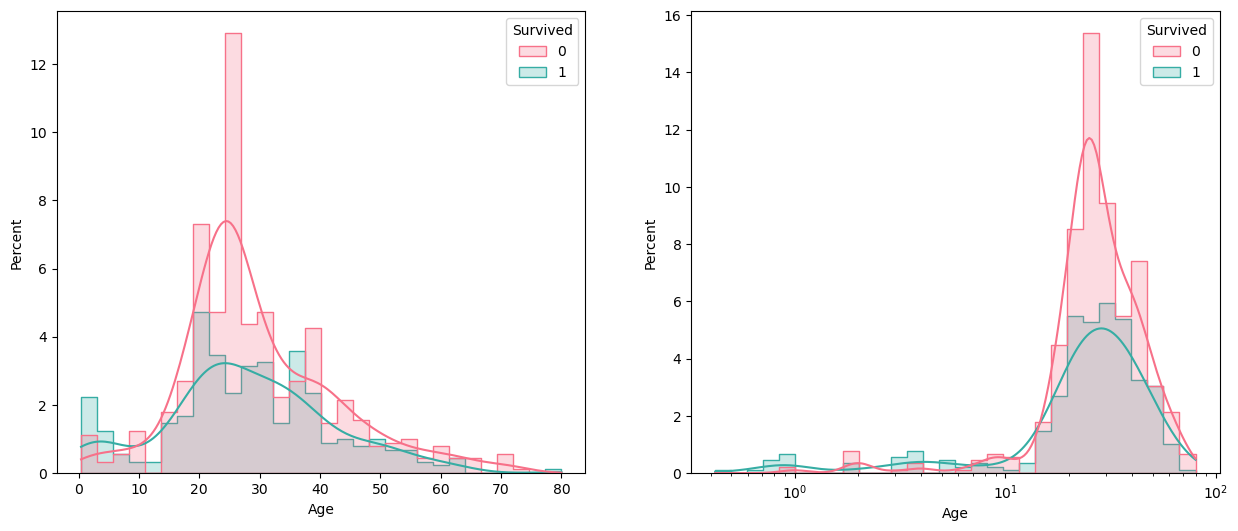

In [ ]:
plt.figure(figsize=(15, 6))
plt.subplot(121)
sns.histplot(data=df, x="Age", hue="Survived", kde=True, palette="husl", 
             element="step", bins=30, stat="percent")
plt.subplot(122)
sns.histplot(data=df, x="Age", hue="Survived", kde=True, palette="husl", 
             element="step", bins=30, stat="percent", log_scale=True)
plt.show()

<Axes: ylabel='Age'>

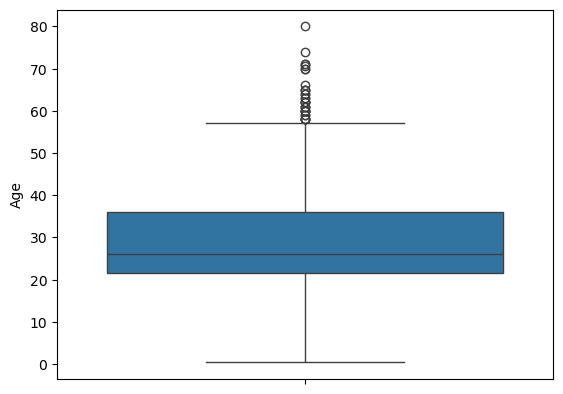

In [ ]:
sns.boxplot(data=df, y="Age")

In [ ]:
df["AgeLog"] = df["Age"].apply(lambda x: np.log(x))

In [ ]:
df.head(2)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,AgeLog
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,7.2500,NaN,S,3.091042
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,71.2833,C85,C,3.637586


<Axes: >

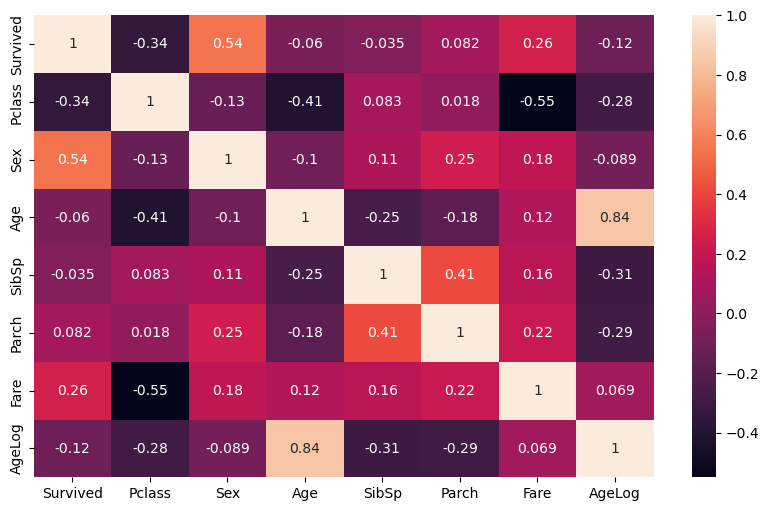

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True)

'AgeLog' is more correlated than 'Age' itself

Survived      0
Pclass        0
Name          0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Cabin       687
Embarked      2
AgeLog        0
dtype: int64


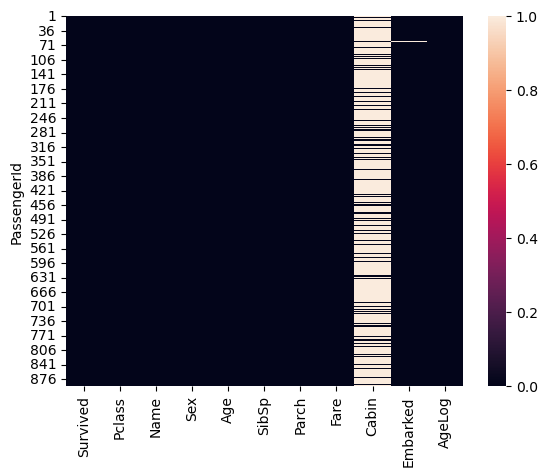

In [ ]:
print(df.isnull().sum())
sns.heatmap(df.isnull())
plt.show()

## Cabin

In [ ]:
df.Cabin.value_counts()

Cabin
B96 B98        4
G6             4
C23 C25 C27    4
C22 C26        3
F33            3
              ..
E34            1
C7             1
C54            1
E36            1
C148           1
Name: count, Length: 147, dtype: int64

In [ ]:
df["Cabin"]= df["Cabin"].astype("str")
df["Cabin"] = df["Cabin"].apply(lambda x: x.replace(x, x[0]) if x not in "nan" else "N")
df.Cabin.value_counts()

Cabin
N    687
C     59
B     47
D     33
E     32
A     15
F     13
G      4
T      1
Name: count, dtype: int64

In [ ]:
df[df["Cabin"] == "T"]

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,AgeLog
PassengerId,,,,,,,,,,,
340,0,1,"Blackwell, Mr. Stephen Weart",0,45.0,0,0,35.5,T,S,3.806662


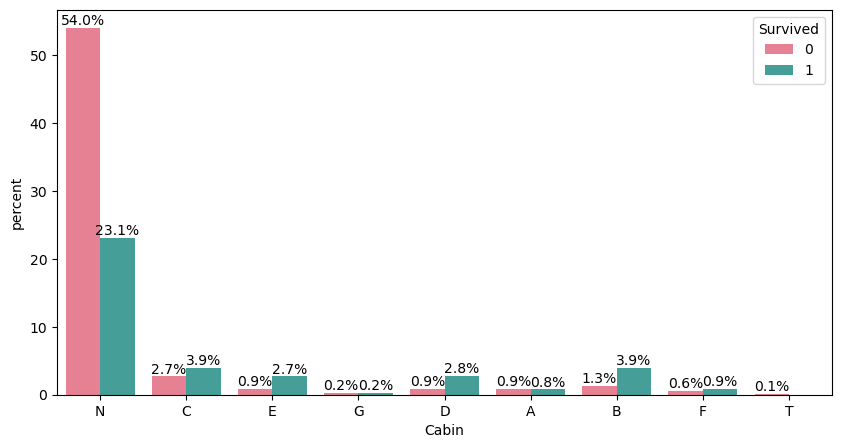

In [ ]:
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, x="Cabin", hue="Survived", stat="percent", palette="husl")
for i in ax.containers:
    ax.bar_label(i, fmt="%.1f%%")

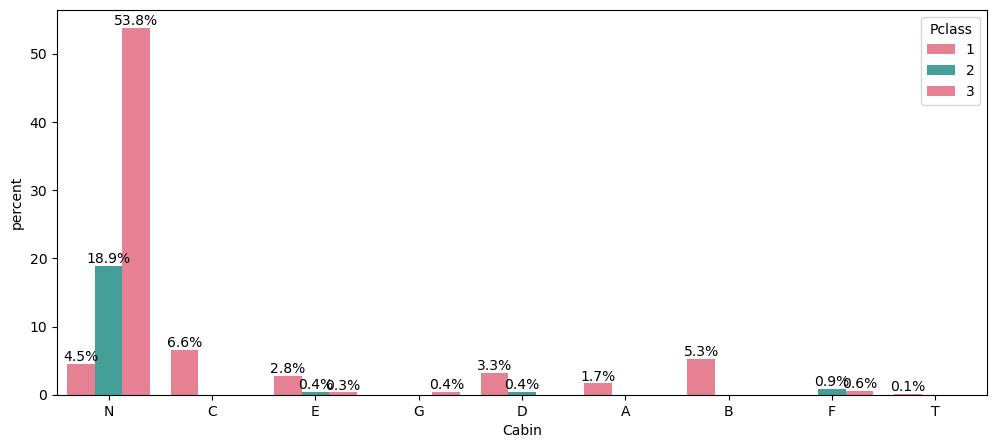

In [ ]:
plt.figure(figsize=(12, 5))
ax = sns.countplot(data=df, x="Cabin", hue="Pclass", stat="percent", palette="husl")
for i in ax.containers:
    ax.bar_label(i, fmt="%.1f%%")

In [ ]:
np.round(df.groupby(["Pclass", "Cabin"])["Survived"].value_counts()/df.shape[0], 2)

Pclass  Cabin  Survived
1       A      0           0.01
               1           0.01
        B      1           0.04
               0           0.01
        C      1           0.04
               0           0.03
        D      1           0.02
               0           0.01
        E      1           0.02
               0           0.01
        N      0           0.02
               1           0.02
        T      0           0.00
2       D      1           0.00
               0           0.00
        E      1           0.00
               0           0.00
        F      1           0.01
               0           0.00
        N      0           0.11
               1           0.08
3       E      1           0.00
        F      0           0.00
               1           0.00
        G      0           0.00
               1           0.00
        N      0           0.41
               1           0.13
Name: count, dtype: float64

In [ ]:
df["HasCabin"] = df["Cabin"].apply(lambda x: 0 if x is "N" else 1).fillna(0)

In [ ]:
df["HasCabin"].value_counts()

HasCabin
0    687
1    204
Name: count, dtype: int64

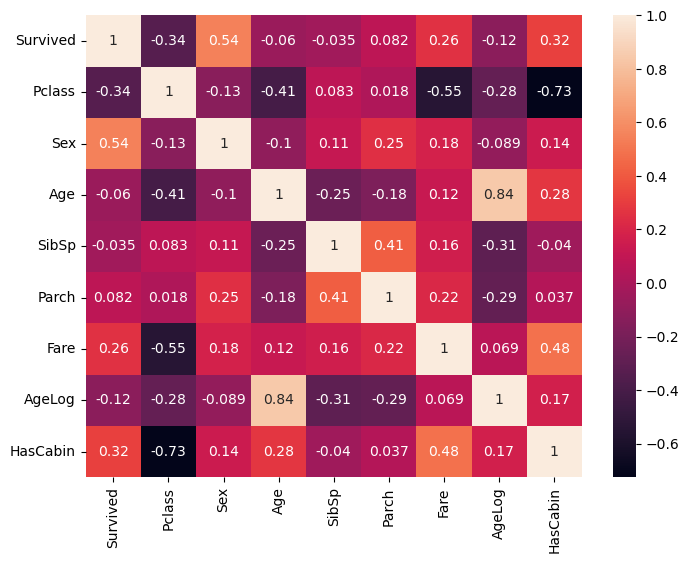

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [ ]:
df.groupby("HasCabin")["Survived"].value_counts() / df.shape[0]

HasCabin  Survived
0         0           0.539843
          1           0.231201
1         1           0.152637
          0           0.076319
Name: count, dtype: float64

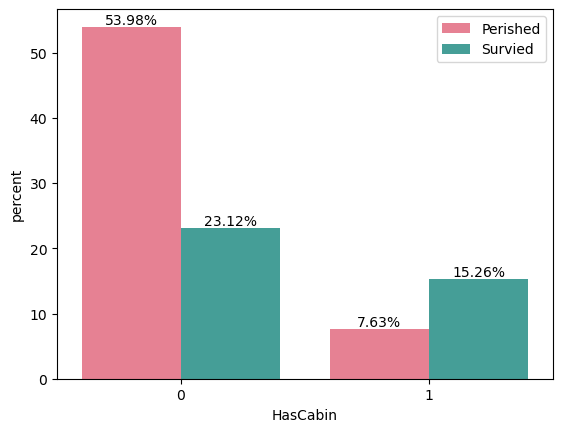

In [ ]:
ax = sns.countplot(data=df, x="HasCabin", hue="Survived", stat="percent", palette="husl")
plt.legend(['Perished', 'Survied'])
for i in ax.containers:
    ax.bar_label(i, fmt="%.2f%%")

It is more likely to survive if the passenger has a cabin

## Embarked

In [ ]:
np.round(df["Embarked"].value_counts()/df.shape[0], 2)

Embarked
S    0.72
C    0.19
Q    0.09
Name: count, dtype: float64

In [ ]:
np.round(df.groupby(["Embarked"])["Survived"].value_counts()/df.shape[0], 2)

Embarked  Survived
C         1           0.10
          0           0.08
Q         0           0.05
          1           0.03
S         0           0.48
          1           0.24
Name: count, dtype: float64

In [ ]:
np.round(df.groupby(["Embarked", "Sex"])["Survived"].value_counts()/df.shape[0], 2)

Embarked  Sex  Survived
C         0    0           0.07
               1           0.03
          1    1           0.07
               0           0.01
Q         0    0           0.04
               1           0.00
          1    1           0.03
               0           0.01
S         0    0           0.41
               1           0.09
          1    1           0.16
               0           0.07
Name: count, dtype: float64

In [ ]:
np.round(df.groupby(["Pclass", "Sex"])["Embarked"].value_counts()/df.shape[0], 2)

Pclass  Sex  Embarked
1       0    S           0.09
             C           0.05
             Q           0.00
        1    S           0.05
             C           0.05
             Q           0.00
2       0    S           0.11
             C           0.01
             Q           0.00
        1    S           0.08
             C           0.01
             Q           0.00
3       0    S           0.30
             C           0.05
             Q           0.04
        1    S           0.10
             Q           0.04
             C           0.03
Name: count, dtype: float64

In [ ]:
df[df.Embarked.isnull()]

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,AgeLog,HasCabin
PassengerId,,,,,,,,,,,,
62,1,1,"Icard, Miss. Amelie",1,38.0,0,0,80.0,B,NaN,3.637586,1
830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",1,62.0,0,0,80.0,B,NaN,4.127134,1


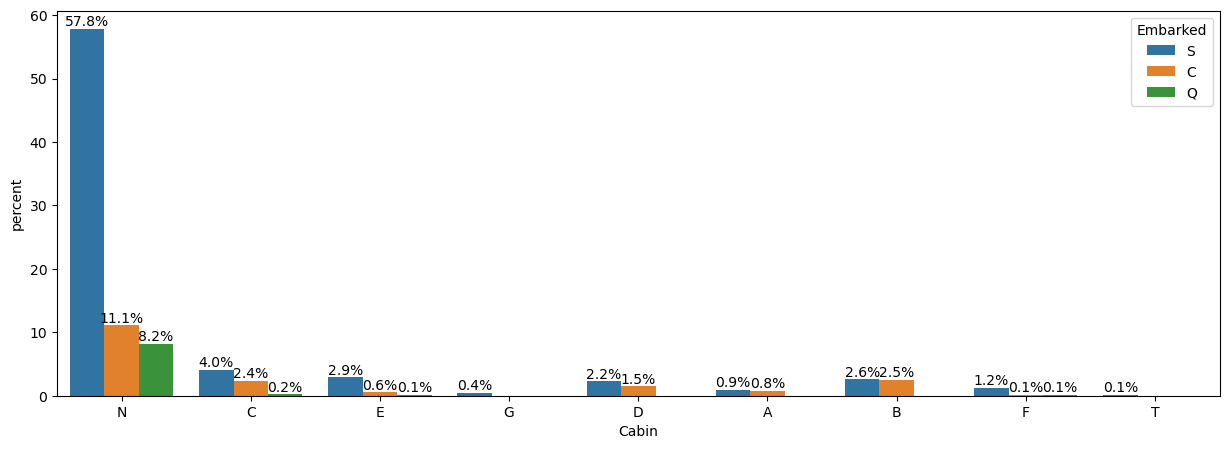

In [ ]:
plt.figure(figsize=(15, 5))
ax = sns.countplot(data=df, x="Cabin", hue="Embarked", stat="percent")
for i in ax.containers:
    ax.bar_label(i, fmt="%.1f%%")

In [ ]:
pd.crosstab([df.Sex, df.Cabin], df.Embarked, margins=True)

Embarked     C   Q    S  All
Sex Cabin                   
0   A        6   0    8   14
    B       10   0   10   20
    C       10   1   21   32
    D        5   0   10   15
    E        1   0   16   17
    F        0   1    7    8
    N       63  39  368  470
    T        0   0    1    1
1   A        1   0    0    1
    B       12   0   13   25
    C       11   1   15   27
    D        8   0   10   18
    E        4   1   10   15
    F        1   0    4    5
    G        0   0    4    4
    N       36  34  147  217
All        168  77  644  889

In [ ]:
df.dropna(subset=["Embarked"], axis=0, inplace=True)

In [ ]:
df["Embarked"].isnull().sum()

0

In [ ]:
pd.crosstab([df["Embarked"], df["HasCabin"]], df["Survived"], margins=True)

Survived             0    1  All
Embarked HasCabin               
C        0          58   41   99
         1          17   52   69
Q        0          45   28   73
         1           2    2    4
S        0         378  137  515
         1          49   80  129
All                549  340  889

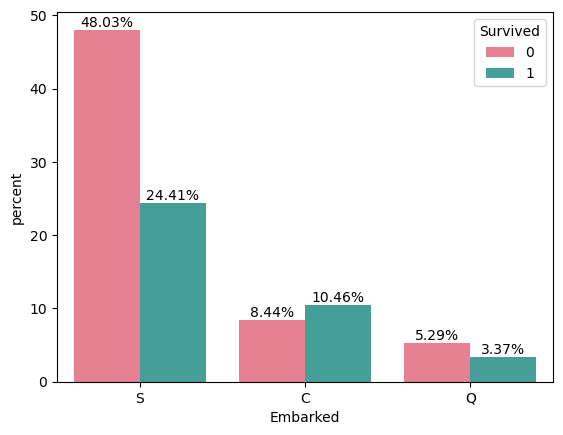

In [ ]:
ax = sns.countplot(data=df, x="Embarked", hue="Survived", palette="husl", stat="percent")
for i in ax.containers:
    ax.bar_label(i, fontsize=10, fmt="%.2f%%")
plt.show()

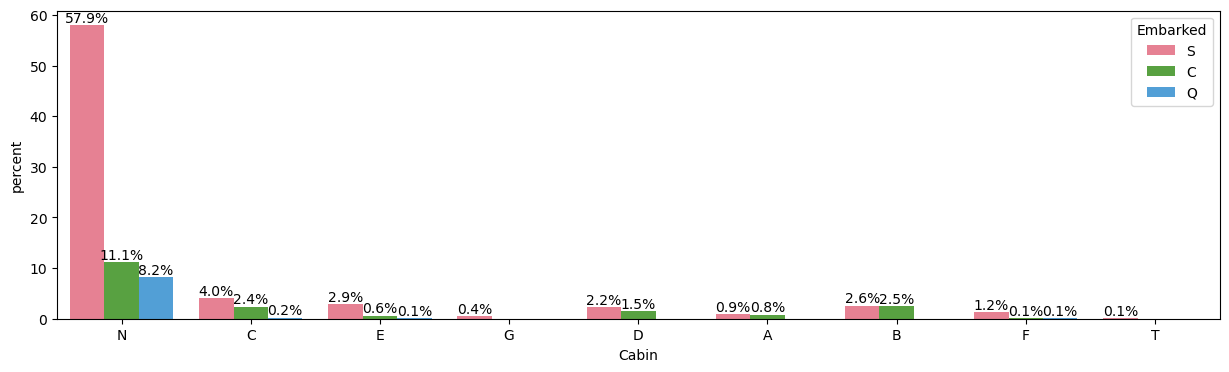

In [ ]:
plt.figure(figsize=(15, 4))
ax = sns.countplot(data=df, x="Cabin", hue="Embarked", palette="husl", stat="percent")
for i in ax.containers:
    ax.bar_label(i, fontsize=10, fmt="%.1f%%")
plt.show()

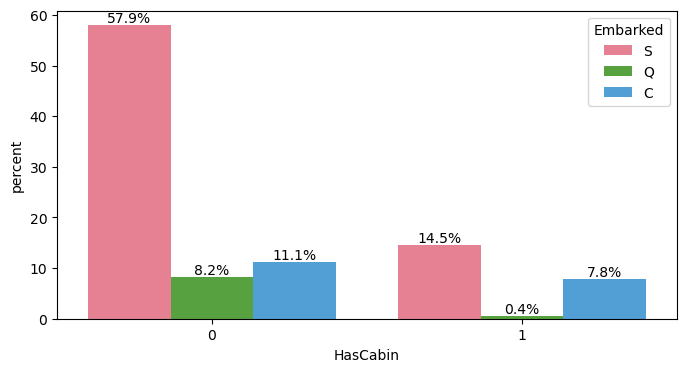

In [ ]:
plt.figure(figsize=(8, 4))
ax = sns.countplot(data=df, x="HasCabin", hue="Embarked", palette="husl", stat="percent")
for i in ax.containers:
    ax.bar_label(i, fontsize=10, fmt="%.1f%%")
plt.show()

In [ ]:
df.isnull().sum()

Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Cabin       0
Embarked    0
AgeLog      0
HasCabin    0
dtype: int64

## Sex

0 -> Male, 1 -> Female

In [ ]:
np.round(df.Survived.value_counts()/df.shape[0], 2)

Survived
0    0.62
1    0.38
Name: count, dtype: float64

In [ ]:
df.groupby("Sex")["Survived"].value_counts()

Sex  Survived
0    0           468
     1           109
1    1           231
     0            81
Name: count, dtype: int64

In [ ]:
sex_survived = np.round(df.groupby("Sex")["Survived"].value_counts() / df.Survived.value_counts(), 2) * 100
sex_survived


Sex  Survived
0    0           85.0
     1           32.0
1    1           68.0
     0           15.0
Name: count, dtype: float64

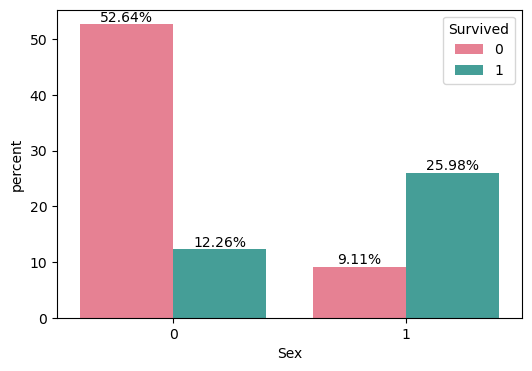

In [ ]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x="Sex", hue="Survived", palette="husl", stat="percent")
for i in ax.containers:
    ax.bar_label(i, fontsize=10, fmt='%.2f%%')

It seems women have more chance to survive

## Pclass

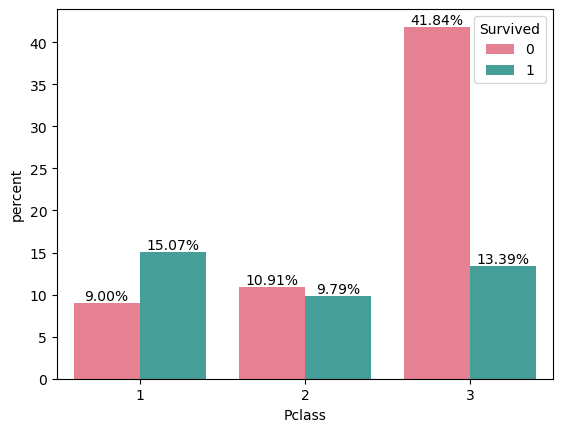

In [ ]:
ax = sns.countplot(data=df, x="Pclass", hue="Survived", palette="husl", stat="percent")
for i in ax.containers:
    ax.bar_label(i, fontsize=10, fmt="%.2f%%")

In [ ]:
pd.crosstab(df.Pclass, df.Survived, margins=True)

Survived,0,1,All
Pclass,,,
1,80,134,214
2,97,87,184
3,372,119,491
All,549,340,889


In [ ]:
np.round((df.groupby(["Pclass"])["Survived"].value_counts() / df.shape[0])*100, 2)

Pclass  Survived
1       1           15.07
        0            9.00
2       0           10.91
        1            9.79
3       0           41.84
        1           13.39
Name: count, dtype: float64

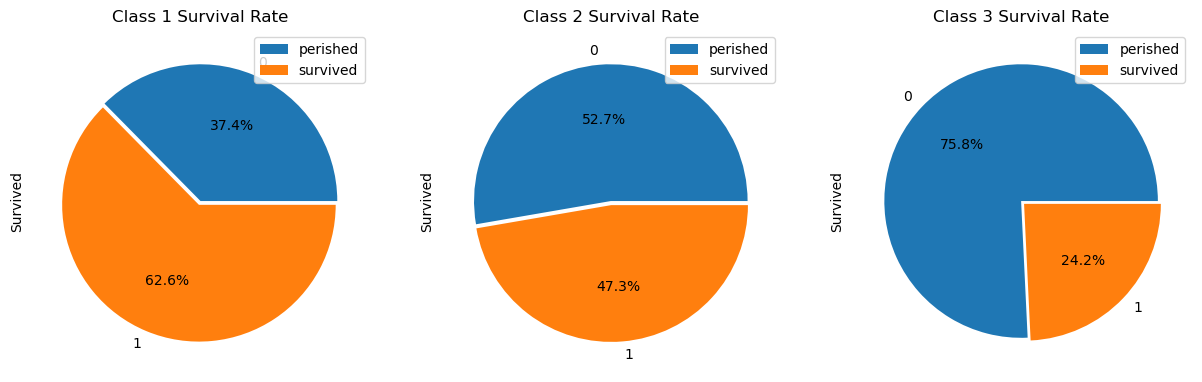

In [ ]:
plt.figure(figsize=(15, 10))
plt.subplot(131)
df[df["Pclass"] == 1].Survived.groupby(df["Survived"]).count().plot(kind="pie", explode=[0,0.03], autopct="%1.1f%%")
plt.legend(["perished", "survived"], loc="upper right")
plt.title("Class 1 Survival Rate")

plt.subplot(132)
df[df["Pclass"] == 2].Survived.groupby(df["Survived"]).count().plot(kind="pie",explode=[0,0.03], autopct="%1.1f%%")
plt.legend(["perished", "survived"], loc="upper right")
plt.title("Class 2 Survival Rate")

plt.subplot(133)
df[df["Pclass"] == 3].Survived.groupby(df["Survived"]).count().plot(kind="pie",explode=[0,0.03], autopct="%1.1f%%")
plt.legend(["perished", "survived"], loc="upper right")
plt.title("Class 3 Survival Rate")


plt.show()

In [ ]:
pd.crosstab([df.Sex, df.Survived], df.Pclass, margins=True)

Pclass          1    2    3  All
Sex Survived                    
0   0          77   91  300  468
    1          45   17   47  109
1   0           3    6   72   81
    1          89   70   72  231
All           214  184  491  889

In [ ]:
pd.crosstab([df.HasCabin, df.Sex],[df.Pclass],  margins=True)

Pclass          1    2    3  All
HasCabin Sex                    
0        0     27  102  341  470
         1     13   66  138  217
1        0     95    6    6  107
         1     79   10    6   95
All           214  184  491  889

## SibSP

No. of Siblings and spouses

In [ ]:
(df["SibSp"].value_counts()/df.shape[0]) * 100

SibSp
0    68.166479
1    23.509561
2     3.149606
4     2.024747
3     1.799775
8     0.787402
5     0.562430
Name: count, dtype: float64

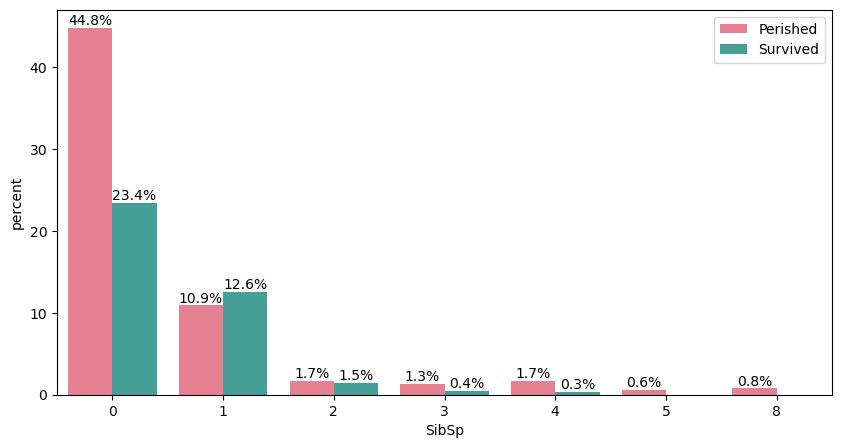

In [ ]:
plt.figure(figsize=(10, 5))
ax = sns.countplot(x="SibSp", data=df, hue="Survived", palette="husl", stat="percent")
plt.legend(["Perished", "Survived"])
for i in ax.containers:
    ax.bar_label(i, fmt="%1.1f%%") 

## Parch

In [ ]:
df["Parch"].value_counts()

Parch
0    676
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

In [ ]:
pd.crosstab(df.Parch, df.Survived, margins=True)

Survived,0,1,All
Parch,,,
0,445,231,676
1,53,65,118
2,40,40,80
3,2,3,5
4,4,0,4
5,4,1,5
6,1,0,1
All,549,340,889


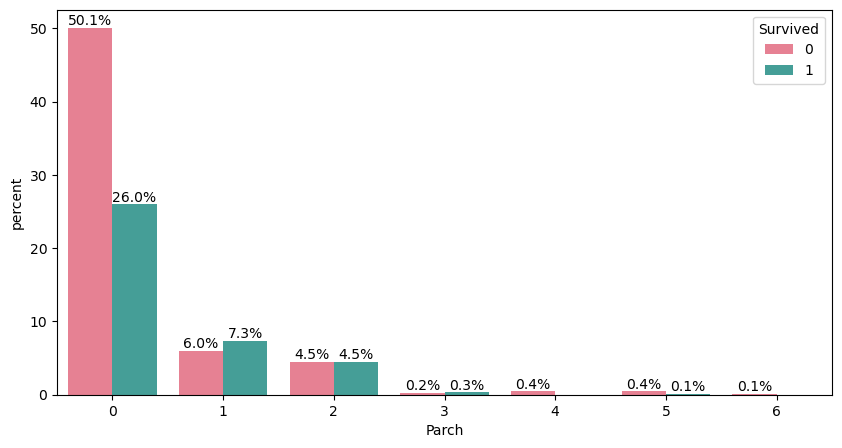

In [ ]:
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, x="Parch", hue="Survived", stat="percent", palette="husl")
for i in ax.containers:
    ax.bar_label(i, fmt="%.1f%%")

In [ ]:
df["HasFamily"] = df["SibSp"] + df["Parch"]

In [ ]:
df["HasFamily"].value_counts()

HasFamily
0     535
1     161
2     102
3      29
5      22
4      15
6      12
10      7
7       6
Name: count, dtype: int64

In [ ]:
df["HasFamily"] = df["HasFamily"].apply(lambda x: 1 if x>=1 else 0)

In [ ]:
np.round((df["HasFamily"].value_counts() / df.shape[0])*100, 2)

HasFamily
0    60.18
1    39.82
Name: count, dtype: float64

In [ ]:
pd.crosstab(df.HasFamily, df.Survived, margins=True)

Survived,0,1,All
HasFamily,,,
0,374,161,535
1,175,179,354
All,549,340,889


<Axes: >

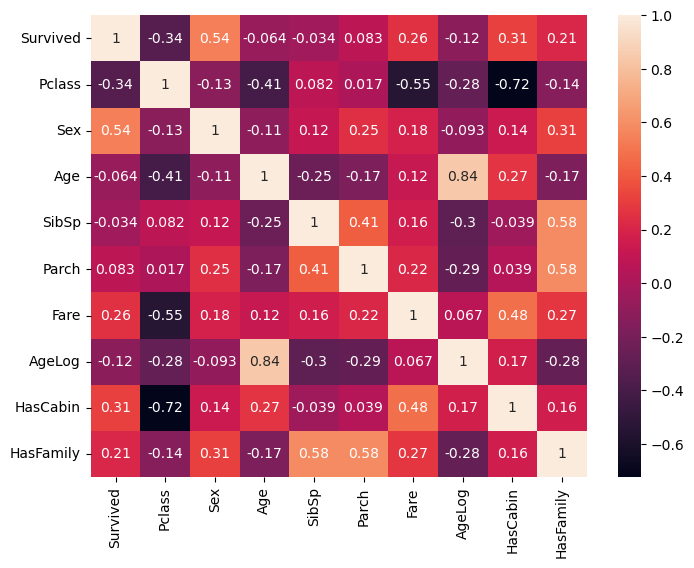

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, )

In [ ]:
df.groupby("HasFamily")["Survived"].value_counts() / df.shape[0]

HasFamily  Survived
0          0           0.420697
           1           0.181102
1          1           0.201350
           0           0.196850
Name: count, dtype: float64

## Fare

In [ ]:
df["Fare"].dtypes

dtype('float64')

In [ ]:
print(df["Fare"].describe())

count    889.000000
mean      32.096681
std       49.697504
min        0.000000
25%        7.895800
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64


<Axes: xlabel='Fare', ylabel='Percent'>

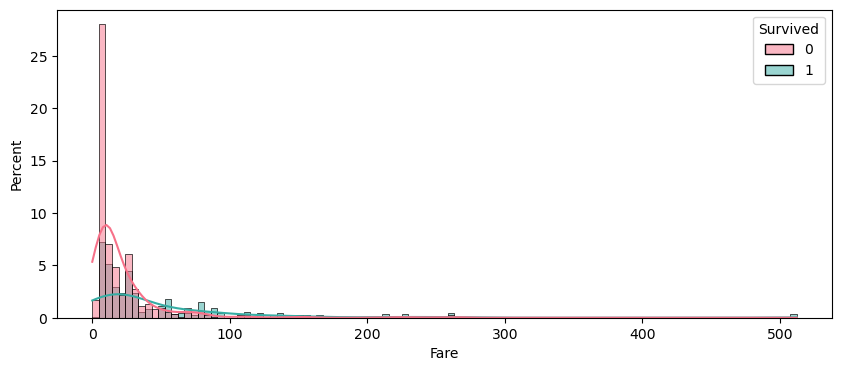

In [ ]:
plt.figure(figsize=(10, 4))
sns.histplot(df, x="Fare", hue="Survived", kde=True, stat="percent", palette="husl")

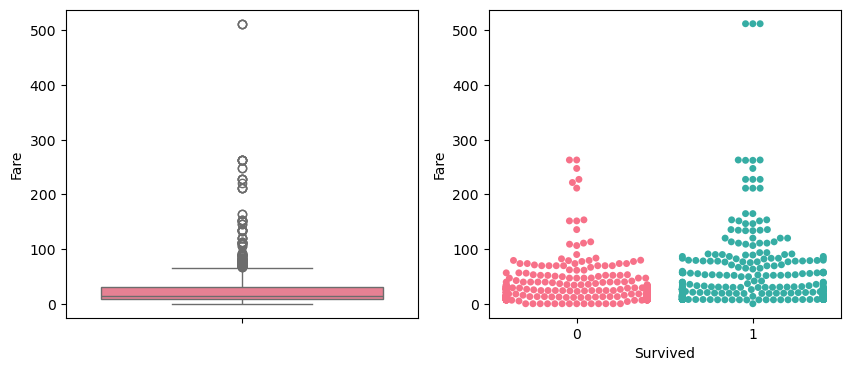

In [ ]:
plt.figure(figsize=(10, 4))
plt.subplot(121)
sns.boxplot(data=df, y="Fare", palette="husl")

plt.subplot(122)
sns.swarmplot(x="Survived", y="Fare", data=df, palette="husl")

plt.show()

In [ ]:
df["FareLog"] = df["Fare"].apply(lambda x: np.log(x))

In [ ]:
df.head(2)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,AgeLog,HasCabin,HasFamily,FareLog
PassengerId,,,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,7.2500,N,S,3.091042,0,1,1.981001
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,71.2833,C,C,3.637586,1,1,4.266662


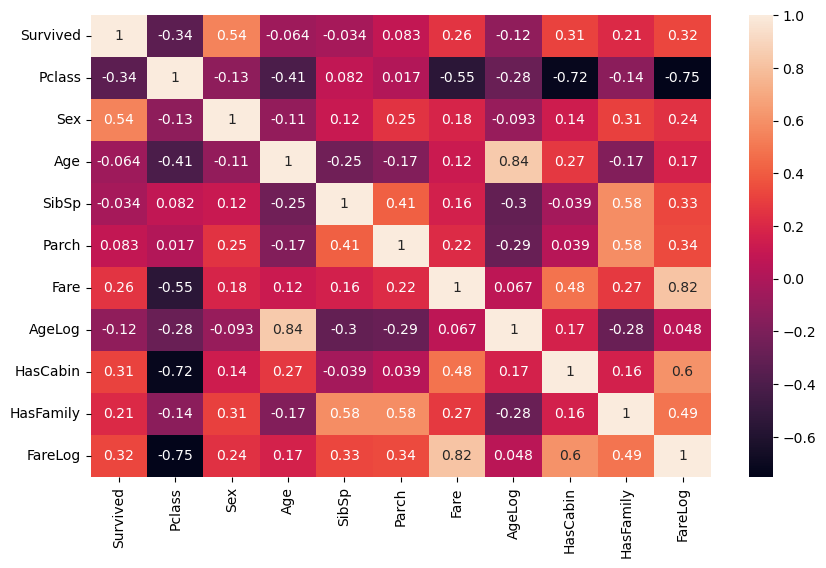

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

"FareLog" is more correlated with Survived.

## Name

In [ ]:
df["Category"] = df["Name"].str.extract(r",\s*([^\.]*)\.", expand=False).str.strip().replace(".", "", regex=False)

In [ ]:
df.head(5)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,AgeLog,HasCabin,HasFamily,FareLog,Category
PassengerId,,,,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,7.2500,N,S,3.091042,0,1,1.981001,Mr
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,71.2833,C,C,3.637586,1,1,4.266662,Mrs
3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,7.9250,N,S,3.258097,0,0,2.070022,Miss
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,53.1000,C,S,3.555348,1,1,3.972177,Mrs
5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,8.0500,N,S,3.555348,0,0,2.085672,Mr


In [ ]:
df["Category"].value_counts()

Category
Mr              517
Miss            181
Mrs             124
Master           40
Dr                7
Rev               6
Mlle              2
Major             2
Col               2
the Countess      1
Capt              1
Ms                1
Sir               1
Lady              1
Mme               1
Don               1
Jonkheer          1
Name: count, dtype: int64

In [ ]:
pd.crosstab([df.Category, df.Sex], df.Survived, margins=True)

Survived            0    1  All
Category     Sex               
Capt         0      1    0    1
Col          0      1    1    2
Don          0      1    0    1
Dr           0      4    2    6
             1      0    1    1
Jonkheer     0      1    0    1
Lady         1      0    1    1
Major        0      1    1    2
Master       0     17   23   40
Miss         1     55  126  181
Mlle         1      0    2    2
Mme          1      0    1    1
Mr           0    436   81  517
Mrs          1     26   98  124
Ms           1      0    1    1
Rev          0      6    0    6
Sir          0      0    1    1
the Countess 1      0    1    1
All               549  340  889

In [ ]:
df["Category"].value_counts()

Category
Mr              517
Miss            181
Mrs             124
Master           40
Dr                7
Rev               6
Mlle              2
Major             2
Col               2
the Countess      1
Capt              1
Ms                1
Sir               1
Lady              1
Mme               1
Don               1
Jonkheer          1
Name: count, dtype: int64

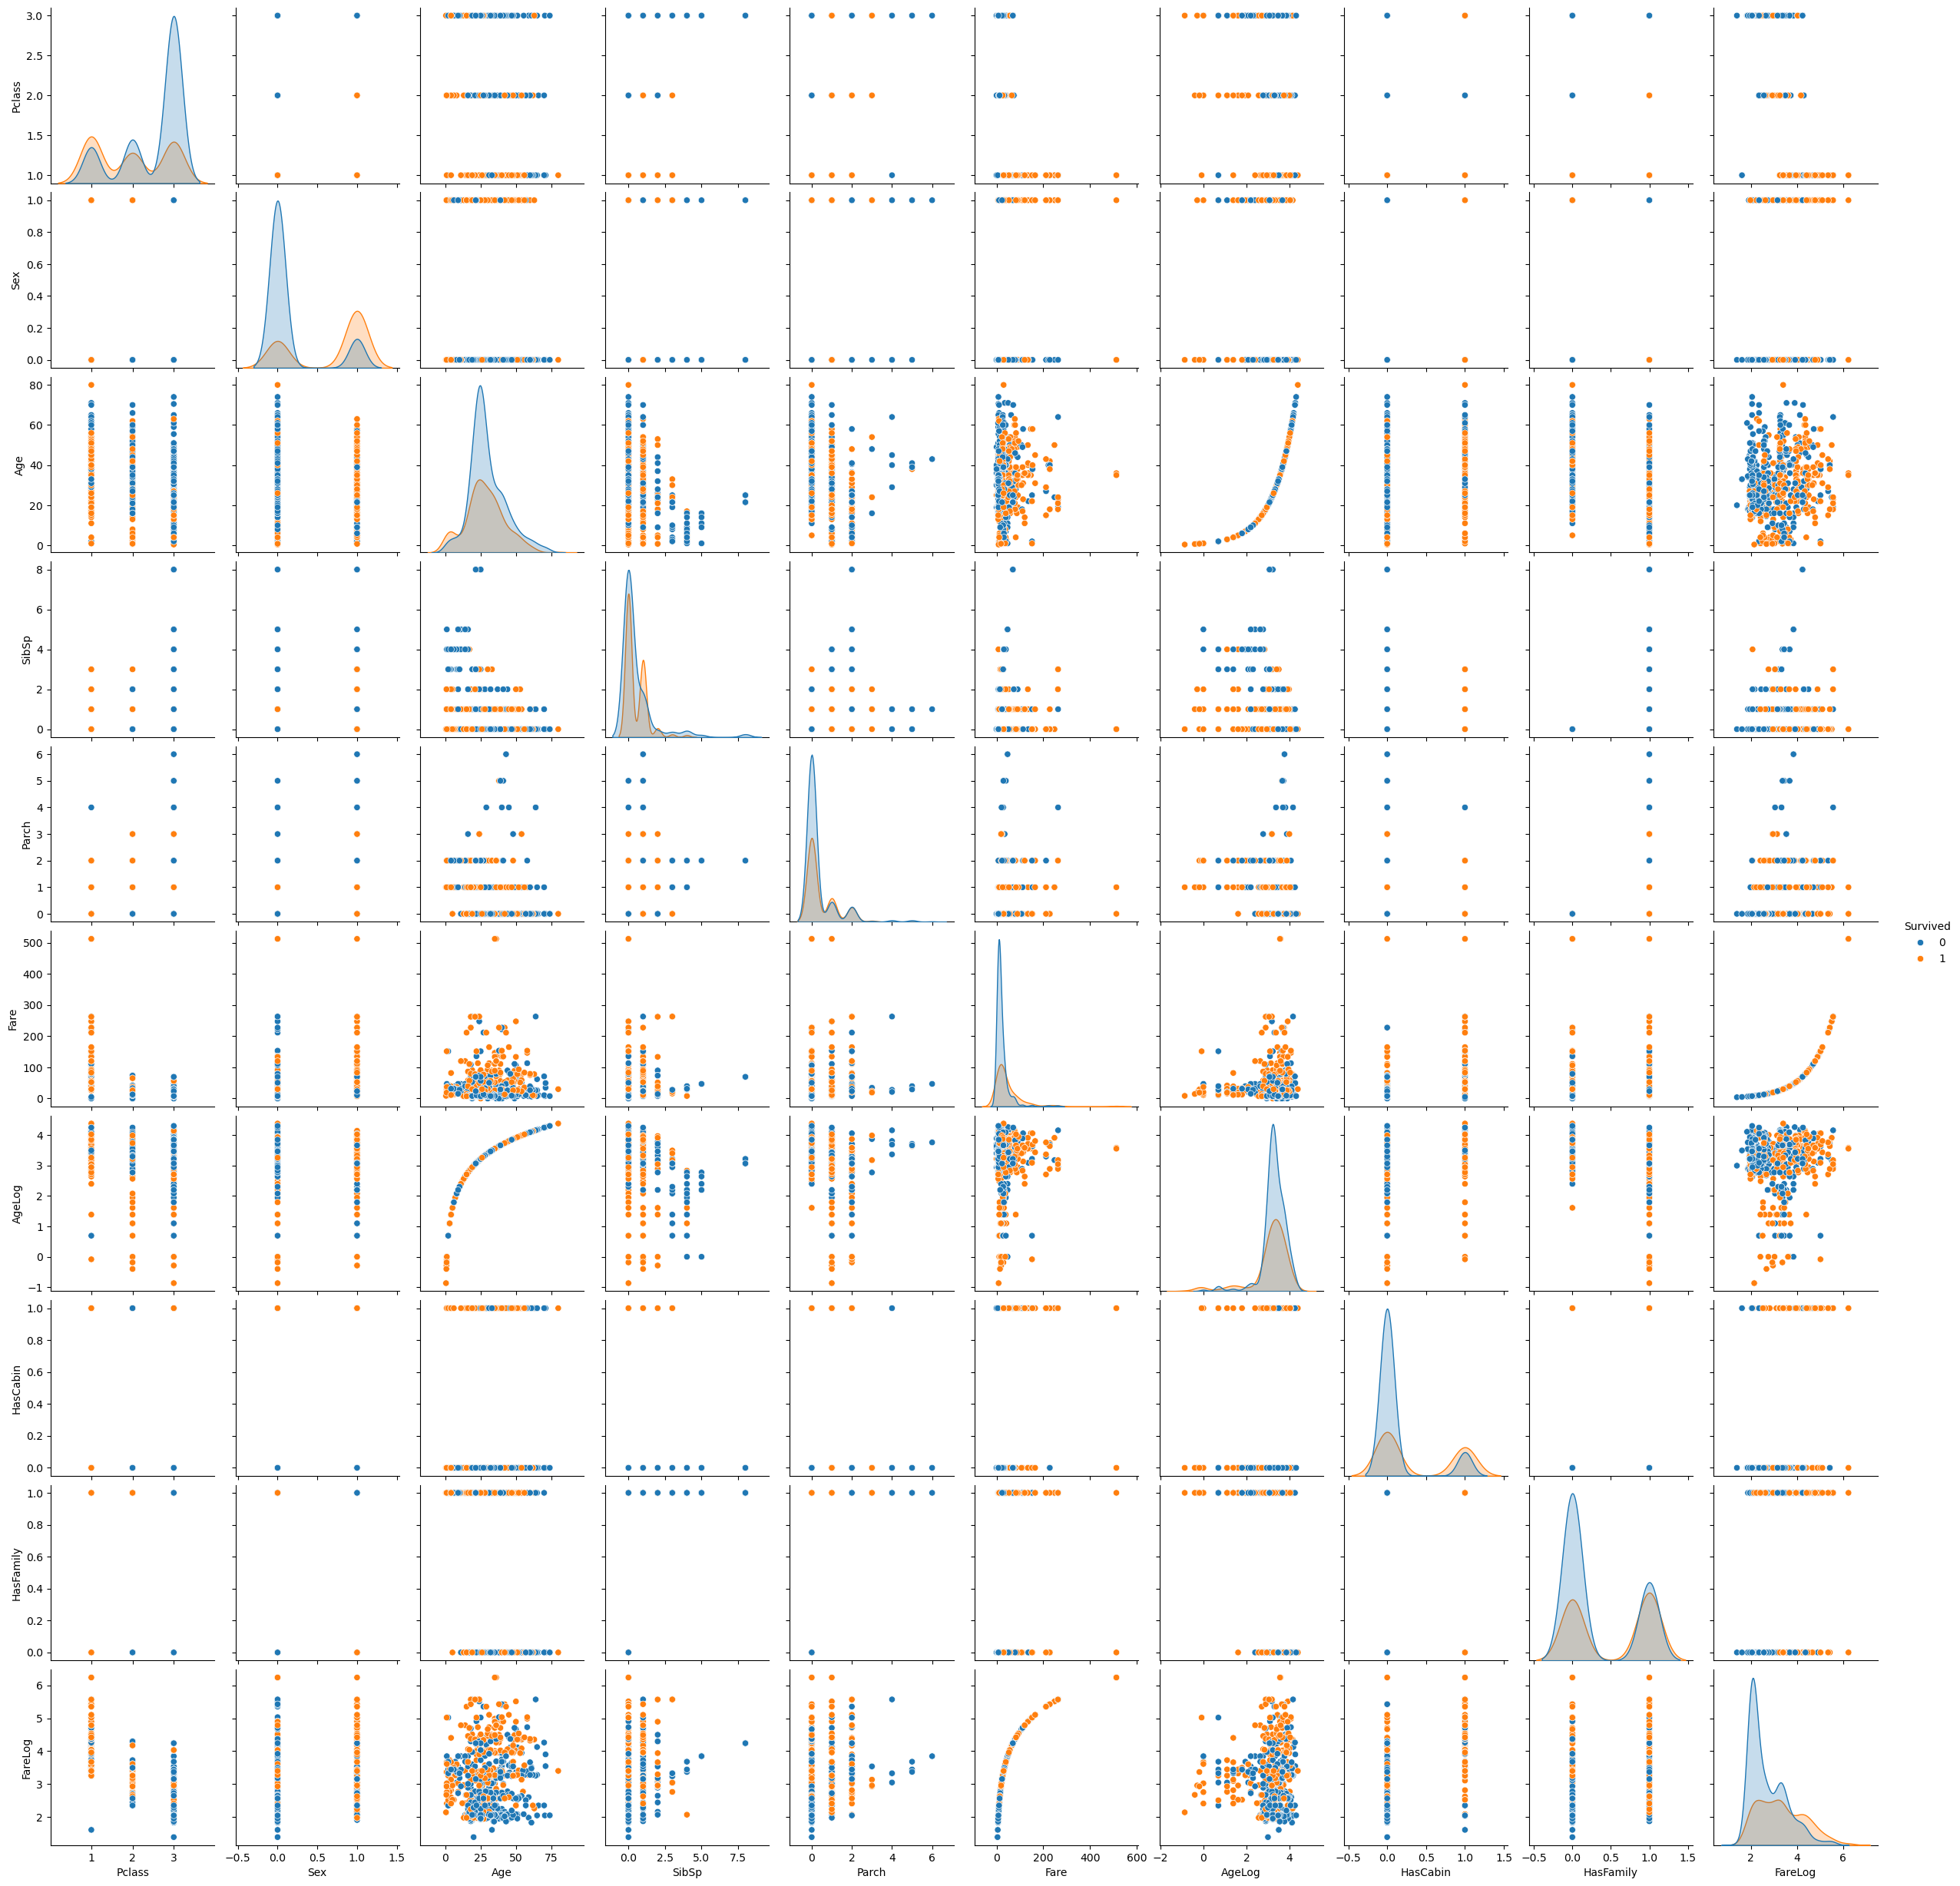

In [ ]:
sns.pairplot(df, hue="Survived")